In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error

# Load final model-ready dataset
df = pd.read_csv("top_3_data/top3_model_ready_training_data.csv")

df["visit_date"] = pd.to_datetime(df["visit_date"])

df.head()

,air_store_id,visit_date,visitors,day_of_week,holiday_flg,month,day,year,week_of_year,day_of_week_num,...,reserved_visitors_mean,avg_reserve_lead_days,has_reservation_data,visitors_lag_1,visitors_lag_7,visitors_lag_14,visitors_lag_28,visitors_rolling_7_mean,visitors_rolling_14_mean,visitors_rolling_28_mean
0,air_36bcf77d3382d36e,2016-01-30,45,Saturday,0,1,30,2016,4,5,...,0.0,0.0,0,31.0,51.0,50.0,34.0,30.714286,28.357143,28.928571
1,air_36bcf77d3382d36e,2016-01-31,56,Sunday,0,1,31,2016,4,6,...,0.0,0.0,0,45.0,47.0,49.0,43.0,29.857143,28.000000,29.321429
2,air_36bcf77d3382d36e,2016-02-01,17,Monday,0,2,1,2016,5,0,...,0.0,0.0,0,56.0,30.0,11.0,30.0,31.142857,28.500000,29.785714
3,air_36bcf77d3382d36e,2016-02-02,9,Tuesday,0,2,2,2016,5,1,...,0.0,0.0,0,17.0,14.0,20.0,38.0,29.285714,28.928571,29.321429
4,air_36bcf77d3382d36e,2016-02-03,16,Wednesday,0,2,3,2016,5,2,...,0.0,0.0,0,9.0,20.0,17.0,22.0,28.571429,28.142857,28.285714


### time-based train-test split

In [3]:
# Sort by date
df = df.sort_values("visit_date")

# Use last 39 days as test period
test_start_date = df["visit_date"].max() - pd.Timedelta(days=38)

train_df = df[df["visit_date"] < test_start_date]
test_df = df[df["visit_date"] >= test_start_date]

print("Training rows:", train_df.shape)
print("Testing rows:", test_df.shape)
print("Test start date:", test_start_date)

Training rows: (1229, 27)
Testing rows: (116, 27)
Test start date: 2017-03-15 00:00:00


In [4]:
target = "visitors"

features = [
    "holiday_flg",
    "month",
    "day",
    "week_of_year",
    "day_of_week_num",
    "is_weekend",
    "latitude",
    "longitude",
    "reserved_visitors_sum",
    "reservation_count",
    "reserved_visitors_mean",
    "avg_reserve_lead_days",
    "has_reservation_data",
    "visitors_lag_1",
    "visitors_lag_7",
    "visitors_lag_14",
    "visitors_lag_28",
    "visitors_rolling_7_mean",
    "visitors_rolling_14_mean",
    "visitors_rolling_28_mean",
    "air_store_id",
    "air_genre_name",
    "air_area_name"
]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [5]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# Make sure both train and test have same columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

In [6]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=12,
    min_samples_leaf=3
)

model.fit(X_train_encoded, y_train)

predictions = model.predict(X_test_encoded)

# Prevent negative predictions
predictions = np.maximum(predictions, 0)

In [7]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
rmsle = np.sqrt(mean_squared_log_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)
print("RMSLE:", rmsle)

MAE: 8.539585499140273
RMSE: 11.434243546531677
RMSLE: 0.4089646069483543


In [8]:
results = test_df[["air_store_id", "visit_date", "visitors"]].copy()
results["predicted_visitors"] = predictions.round(0).astype(int)
results["error"] = abs(results["visitors"] - results["predicted_visitors"])

results.head(20)

,air_store_id,visit_date,visitors,predicted_visitors,error
409,air_36bcf77d3382d36e,2017-03-15,21,19,2
1307,air_a083834e7ffe187e,2017-03-15,18,15,3
858,air_5c817ef28f236bdf,2017-03-15,12,31,19
410,air_36bcf77d3382d36e,2017-03-16,24,20,4
1308,air_a083834e7ffe187e,2017-03-16,8,14,6
859,air_5c817ef28f236bdf,2017-03-16,30,30,0
411,air_36bcf77d3382d36e,2017-03-17,27,27,0
860,air_5c817ef28f236bdf,2017-03-17,54,49,5
1309,air_a083834e7ffe187e,2017-03-17,43,46,3
861,air_5c817ef28f236bdf,2017-03-18,71,82,11


In [9]:
daily_predictions = results.copy()

daily_predictions["week_start"] = (
    daily_predictions["visit_date"] 
    - pd.to_timedelta(daily_predictions["visit_date"].dt.weekday, unit="D")
)

daily_predictions["week_end"] = daily_predictions["week_start"] + pd.Timedelta(days=6)

weekly_predictions = (
    daily_predictions
    .groupby(["air_store_id", "week_start", "week_end"])
    .agg(
        actual_weekly_visitors=("visitors", "sum"),
        predicted_weekly_visitors=("predicted_visitors", "sum"),
        average_daily_error=("error", "mean")
    )
    .reset_index()
)

weekly_predictions

,air_store_id,week_start,week_end,actual_weekly_visitors,predicted_weekly_visitors,average_daily_error
0,air_36bcf77d3382d36e,2017-03-13,2017-03-19,143,185,10.800000
1,air_36bcf77d3382d36e,2017-03-20,2017-03-26,229,234,8.428571
2,air_36bcf77d3382d36e,2017-03-27,2017-04-02,192,217,7.000000
3,air_36bcf77d3382d36e,2017-04-03,2017-04-09,230,197,6.428571
4,air_36bcf77d3382d36e,2017-04-10,2017-04-16,231,202,7.857143
5,air_36bcf77d3382d36e,2017-04-17,2017-04-23,157,175,8.666667
6,air_5c817ef28f236bdf,2017-03-13,2017-03-19,255,242,14.600000
7,air_5c817ef28f236bdf,2017-03-20,2017-03-26,299,314,13.857143
8,air_5c817ef28f236bdf,2017-03-27,2017-04-02,345,294,12.714286
9,air_5c817ef28f236bdf,2017-04-03,2017-04-09,299,283,8.000000


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score
import numpy as np
import pandas as pd

# Make sure predictions are not negative
predictions = np.maximum(predictions, 0)

# Evaluation metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
rmsle = np.sqrt(mean_squared_log_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

# Practical accuracy estimate
mean_actual_visitors = y_test.mean()
practical_accuracy = (1 - (mae / mean_actual_visitors)) * 100

print("MODEL EVALUATION RESULTS")
print("-------------------------")
print(f"MAE  - Average error in visitors: {mae:.2f}")
print(f"RMSE - Root mean squared error: {rmse:.2f}")
print(f"RMSLE - Log error score: {rmsle:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean actual visitors: {mean_actual_visitors:.2f}")
print(f"Practical accuracy estimate: {practical_accuracy:.2f}%")

MODEL EVALUATION RESULTS
-------------------------
MAE  - Average error in visitors: 8.54
RMSE - Root mean squared error: 11.43
RMSLE - Log error score: 0.4090
R² Score: 0.6866
Mean actual visitors: 33.28
Practical accuracy estimate: 74.34%


I feel the test and train splut was not fair as we need more unique split for each restaurant as we need to predict for each restaurant based on their data

In [2]:
# ============================================================
# MODEL TRAINING AND EVALUATION
# Per-restaurant time-based split
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 1. Load final model-ready dataset
# ------------------------------------------------------------

DATA_DIR = Path("top_3_data")

df = pd.read_csv(DATA_DIR / "top3_model_ready_training_data.csv")

df["visit_date"] = pd.to_datetime(df["visit_date"])

df = df.sort_values(["air_store_id", "visit_date"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Restaurants:", df["air_store_id"].nunique())
print("Date range:", df["visit_date"].min(), "to", df["visit_date"].max())

df.head()

Dataset shape: (1345, 27)
Restaurants: 3
Date range: 2016-01-29 00:00:00 to 2017-04-22 00:00:00


,air_store_id,visit_date,visitors,day_of_week,holiday_flg,month,day,year,week_of_year,day_of_week_num,...,reserved_visitors_mean,avg_reserve_lead_days,has_reservation_data,visitors_lag_1,visitors_lag_7,visitors_lag_14,visitors_lag_28,visitors_rolling_7_mean,visitors_rolling_14_mean,visitors_rolling_28_mean
0,air_36bcf77d3382d36e,2016-01-30,45,Saturday,0,1,30,2016,4,5,...,0.0,0.0,0,31.0,51.0,50.0,34.0,30.714286,28.357143,28.928571
1,air_36bcf77d3382d36e,2016-01-31,56,Sunday,0,1,31,2016,4,6,...,0.0,0.0,0,45.0,47.0,49.0,43.0,29.857143,28.000000,29.321429
2,air_36bcf77d3382d36e,2016-02-01,17,Monday,0,2,1,2016,5,0,...,0.0,0.0,0,56.0,30.0,11.0,30.0,31.142857,28.500000,29.785714
3,air_36bcf77d3382d36e,2016-02-02,9,Tuesday,0,2,2,2016,5,1,...,0.0,0.0,0,17.0,14.0,20.0,38.0,29.285714,28.928571,29.321429
4,air_36bcf77d3382d36e,2016-02-03,16,Wednesday,0,2,3,2016,5,2,...,0.0,0.0,0,9.0,20.0,17.0,22.0,28.571429,28.142857,28.285714


In [3]:
# ------------------------------------------------------------
# 2. Per-restaurant time-based train/test split
# ------------------------------------------------------------

TEST_DAYS = 39

train_parts = []
test_parts = []

for restaurant_id in df["air_store_id"].unique():
    restaurant_df = df[df["air_store_id"] == restaurant_id].copy()
    restaurant_df = restaurant_df.sort_values("visit_date")

    test_df_restaurant = restaurant_df.tail(TEST_DAYS)
    train_df_restaurant = restaurant_df.iloc[:-TEST_DAYS]

    train_parts.append(train_df_restaurant)
    test_parts.append(test_df_restaurant)

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print("Training rows:", train_df.shape)
print("Testing rows:", test_df.shape)

print("\nTrain rows per restaurant:")
print(train_df["air_store_id"].value_counts())

print("\nTest rows per restaurant:")
print(test_df["air_store_id"].value_counts())

print("\nTest date range per restaurant:")
print(test_df.groupby("air_store_id")["visit_date"].agg(["min", "max"]))

Training rows: (1228, 27)
Testing rows: (117, 27)

Train rows per restaurant:
air_store_id
air_5c817ef28f236bdf    410
air_36bcf77d3382d36e    409
air_a083834e7ffe187e    409
Name: count, dtype: int64

Test rows per restaurant:
air_store_id
air_36bcf77d3382d36e    39
air_5c817ef28f236bdf    39
air_a083834e7ffe187e    39
Name: count, dtype: int64

Test date range per restaurant:
                            min        max
air_store_id                              
air_36bcf77d3382d36e 2017-03-15 2017-04-22
air_5c817ef28f236bdf 2017-03-15 2017-04-22
air_a083834e7ffe187e 2017-03-14 2017-04-22


In [4]:
# ------------------------------------------------------------
# 3. Feature selection
# ------------------------------------------------------------

target = "visitors"

USE_LAG_1 = True

features = [
    # Calendar features
    "holiday_flg",
    "month",
    "day",
    "year",
    "week_of_year",
    "day_of_week_num",
    "is_weekend",

    # Location features
    "latitude",
    "longitude",

    # Reservation features
    "reserved_visitors_sum",
    "reservation_count",
    "reserved_visitors_mean",
    "avg_reserve_lead_days",
    "has_reservation_data",

    # Historical visitor features
    "visitors_lag_7",
    "visitors_lag_14",
    "visitors_lag_28",
    "visitors_rolling_7_mean",
    "visitors_rolling_14_mean",
    "visitors_rolling_28_mean",

    # Categorical restaurant features
    "air_store_id",
    "air_genre_name",
    "air_area_name"
]

if USE_LAG_1:
    features.append("visitors_lag_1")

# Keep only features that actually exist in your dataset
features = [col for col in features if col in df.columns]

print("Number of features used:", len(features))
print(features)

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

Number of features used: 24
['holiday_flg', 'month', 'day', 'year', 'week_of_year', 'day_of_week_num', 'is_weekend', 'latitude', 'longitude', 'reserved_visitors_sum', 'reservation_count', 'reserved_visitors_mean', 'avg_reserve_lead_days', 'has_reservation_data', 'visitors_lag_7', 'visitors_lag_14', 'visitors_lag_28', 'visitors_rolling_7_mean', 'visitors_rolling_14_mean', 'visitors_rolling_28_mean', 'air_store_id', 'air_genre_name', 'air_area_name', 'visitors_lag_1']


In [5]:
# ------------------------------------------------------------
# 4. One-hot encode categorical features
# ------------------------------------------------------------

X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# Make sure train and test have same columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (1228, 29)
Encoded testing shape: (117, 29)


In [6]:
# ------------------------------------------------------------
# 5. Train Random Forest model
# ------------------------------------------------------------

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=12,
    min_samples_leaf=3,
    max_features="sqrt"
)

model.fit(X_train_encoded, y_train)

predictions = model.predict(X_test_encoded)

# Avoid negative visitor predictions
predictions = np.maximum(predictions, 0)

print("Model training complete.")

Model training complete.


In [7]:
# ------------------------------------------------------------
# 6. Overall evaluation metrics
# ------------------------------------------------------------

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
rmsle = np.sqrt(mean_squared_log_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

mean_actual_visitors = y_test.mean()
practical_accuracy = (1 - (mae / mean_actual_visitors)) * 100

print("MODEL EVALUATION RESULTS")
print("-------------------------")
print(f"MAE  - Average error in visitors: {mae:.2f}")
print(f"RMSE - Root mean squared error: {rmse:.2f}")
print(f"RMSLE - Log error score: {rmsle:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean actual visitors: {mean_actual_visitors:.2f}")
print(f"Practical accuracy estimate: {practical_accuracy:.2f}%")

MODEL EVALUATION RESULTS
-------------------------
MAE  - Average error in visitors: 8.39
RMSE - Root mean squared error: 11.24
RMSLE - Log error score: 0.4144
R² Score: 0.6971
Mean actual visitors: 33.11
Practical accuracy estimate: 74.67%


In [8]:
# ------------------------------------------------------------
# 7. Actual vs predicted results
# ------------------------------------------------------------

results = test_df[["air_store_id", "visit_date", "visitors"]].copy()

results["predicted_visitors"] = predictions
results["predicted_visitors_rounded"] = np.round(predictions).astype(int)
results["absolute_error"] = abs(results["visitors"] - results["predicted_visitors"])
results["absolute_error_rounded"] = abs(results["visitors"] - results["predicted_visitors_rounded"])

results.head(20)

,air_store_id,visit_date,visitors,predicted_visitors,predicted_visitors_rounded,absolute_error,absolute_error_rounded
0,air_36bcf77d3382d36e,2017-03-15,21,20.541793,21,0.458207,0
1,air_36bcf77d3382d36e,2017-03-16,24,21.693643,22,2.306357,2
2,air_36bcf77d3382d36e,2017-03-17,27,26.873733,27,0.126267,0
3,air_36bcf77d3382d36e,2017-03-18,30,61.860501,62,31.860501,32
4,air_36bcf77d3382d36e,2017-03-19,41,53.277259,53,12.277259,12
5,air_36bcf77d3382d36e,2017-03-20,58,36.764964,37,21.235036,21
6,air_36bcf77d3382d36e,2017-03-21,15,20.668553,21,5.668553,6
7,air_36bcf77d3382d36e,2017-03-22,14,21.827057,22,7.827057,8
8,air_36bcf77d3382d36e,2017-03-23,19,20.426206,20,1.426206,1
9,air_36bcf77d3382d36e,2017-03-24,13,31.533023,32,18.533023,19


In [9]:
results.to_csv(DATA_DIR / "daily_prediction_results_per_restaurant_split.csv", index=False)

print("Daily prediction results saved.")

Daily prediction results saved.


In [10]:
# ------------------------------------------------------------
# 8. Per-restaurant evaluation
# ------------------------------------------------------------

restaurant_metrics = []

for restaurant_id in results["air_store_id"].unique():
    temp = results[results["air_store_id"] == restaurant_id]

    y_true_rest = temp["visitors"]
    y_pred_rest = temp["predicted_visitors"]

    rest_mae = mean_absolute_error(y_true_rest, y_pred_rest)
    rest_rmse = np.sqrt(mean_squared_error(y_true_rest, y_pred_rest))
    rest_r2 = r2_score(y_true_rest, y_pred_rest)

    rest_mean_actual = y_true_rest.mean()
    rest_accuracy = (1 - (rest_mae / rest_mean_actual)) * 100

    restaurant_metrics.append({
        "air_store_id": restaurant_id,
        "test_rows": len(temp),
        "mean_actual_visitors": rest_mean_actual,
        "mae": rest_mae,
        "rmse": rest_rmse,
        "r2_score": rest_r2,
        "practical_accuracy_percent": rest_accuracy
    })

restaurant_metrics_df = pd.DataFrame(restaurant_metrics)

restaurant_metrics_df

,air_store_id,test_rows,mean_actual_visitors,mae,rmse,r2_score,practical_accuracy_percent
0,air_36bcf77d3382d36e,39,30.307692,8.043493,10.557405,0.611964,73.460556
1,air_5c817ef28f236bdf,39,44.923077,11.922459,14.754999,0.607834,73.460280
2,air_a083834e7ffe187e,39,24.102564,5.196668,7.039348,0.723985,78.439356


In [11]:
restaurant_metrics_df.to_csv(DATA_DIR / "restaurant_level_model_metrics.csv", index=False)

print("Restaurant-level metrics saved.")

Restaurant-level metrics saved.


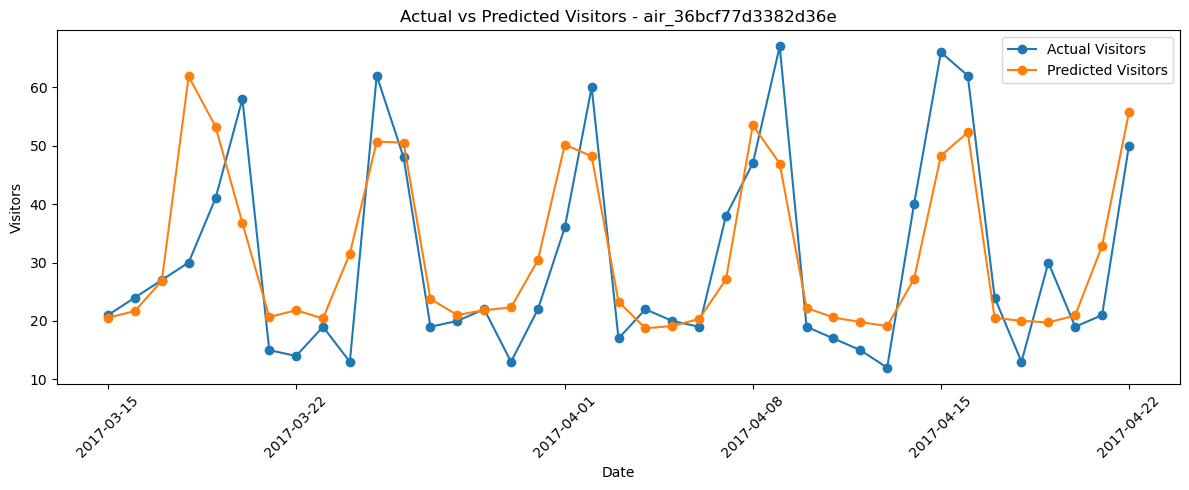

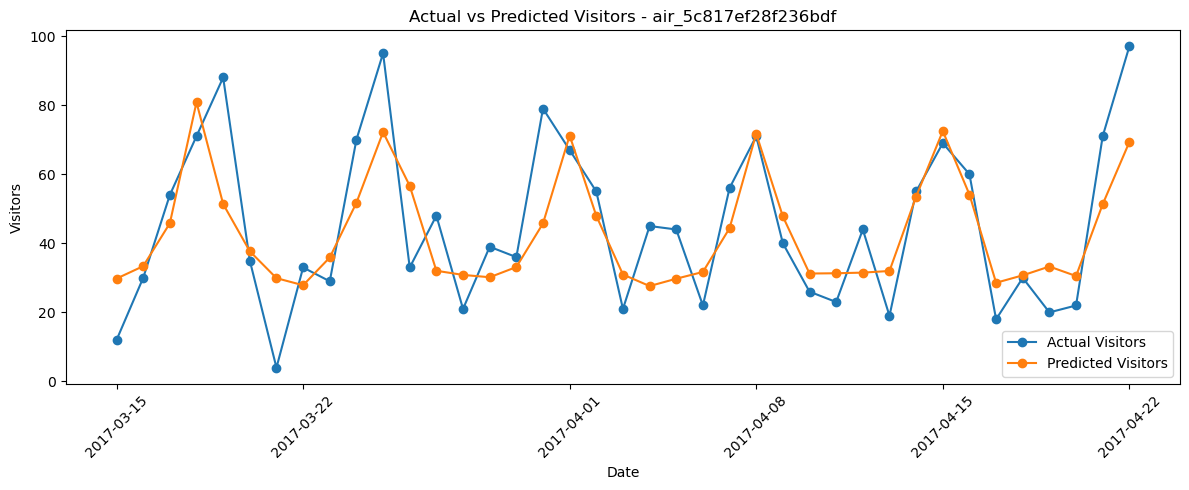

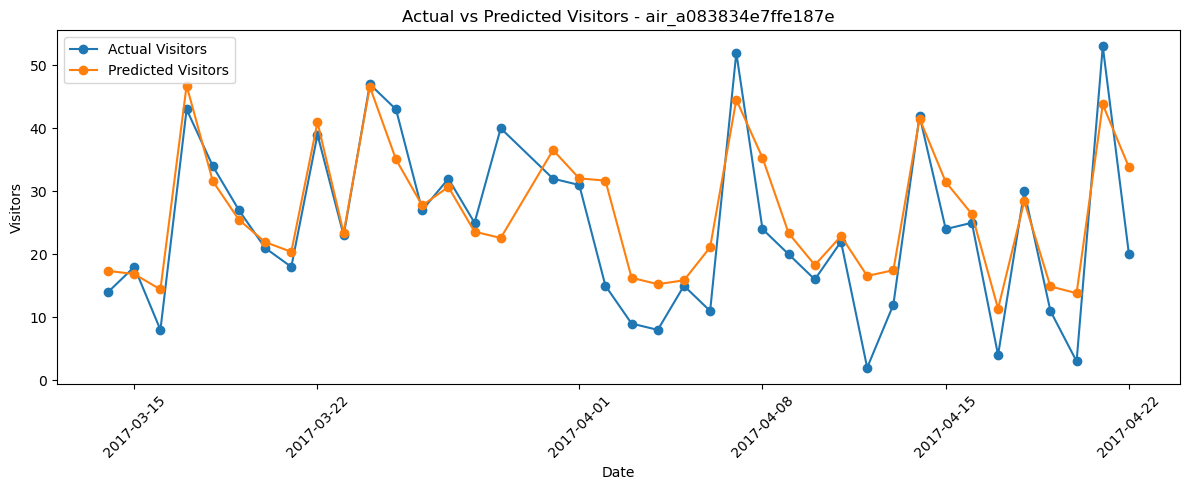

In [12]:
# ------------------------------------------------------------
# 9. Plot actual vs predicted visitors for each restaurant
# ------------------------------------------------------------

for restaurant_id in results["air_store_id"].unique():
    temp = results[results["air_store_id"] == restaurant_id].copy()

    plt.figure(figsize=(12, 5))
    plt.plot(temp["visit_date"], temp["visitors"], marker="o", label="Actual Visitors")
    plt.plot(temp["visit_date"], temp["predicted_visitors"], marker="o", label="Predicted Visitors")

    plt.title(f"Actual vs Predicted Visitors - {restaurant_id}")
    plt.xlabel("Date")
    plt.ylabel("Visitors")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
# ------------------------------------------------------------
# 10. Aggregate daily predictions into weekly predictions
# ------------------------------------------------------------

daily_predictions = results.copy()

daily_predictions["visit_date"] = pd.to_datetime(daily_predictions["visit_date"])

# Week starts on Monday
daily_predictions["week_start"] = (
    daily_predictions["visit_date"]
    - pd.to_timedelta(daily_predictions["visit_date"].dt.weekday, unit="D")
)

daily_predictions["week_end"] = daily_predictions["week_start"] + pd.Timedelta(days=6)

weekly_predictions = (
    daily_predictions
    .groupby(["air_store_id", "week_start", "week_end"])
    .agg(
        days_in_week=("visit_date", "count"),
        actual_weekly_visitors=("visitors", "sum"),
        predicted_weekly_visitors=("predicted_visitors", "sum"),
        predicted_weekly_visitors_rounded=("predicted_visitors_rounded", "sum"),
        average_daily_error=("absolute_error", "mean")
    )
    .reset_index()
)

weekly_predictions["weekly_absolute_error"] = abs(
    weekly_predictions["actual_weekly_visitors"]
    - weekly_predictions["predicted_weekly_visitors"]
)

weekly_predictions["weekly_practical_accuracy_percent"] = (
    1 - (
        weekly_predictions["weekly_absolute_error"]
        / weekly_predictions["actual_weekly_visitors"]
    )
) * 100

weekly_predictions

,air_store_id,week_start,week_end,days_in_week,actual_weekly_visitors,predicted_weekly_visitors,predicted_weekly_visitors_rounded,average_daily_error,weekly_absolute_error,weekly_practical_accuracy_percent
0,air_36bcf77d3382d36e,2017-03-13,2017-03-19,5,143,184.246928,185,9.405718,41.246928,71.155994
1,air_36bcf77d3382d36e,2017-03-20,2017-03-26,7,229,232.442407,234,9.790082,3.442407,98.496765
2,air_36bcf77d3382d36e,2017-03-27,2017-04-02,7,192,217.716900,217,7.091003,25.716900,86.605781
3,air_36bcf77d3382d36e,2017-04-03,2017-04-09,7,230,209.081531,209,7.031488,20.918469,90.905013
4,air_36bcf77d3382d36e,2017-04-10,2017-04-16,7,231,209.493149,209,8.431653,21.506851,90.689675
5,air_36bcf77d3382d36e,2017-04-17,2017-04-23,6,157,169.771533,171,6.709675,12.771533,91.865265
6,air_5c817ef28f236bdf,2017-03-13,2017-03-19,5,255,241.143634,241,15.159488,13.856366,94.566131
7,air_5c817ef28f236bdf,2017-03-20,2017-03-26,7,299,311.894680,313,15.052331,12.894680,95.687398
8,air_5c817ef28f236bdf,2017-03-27,2017-04-02,7,345,291.093048,291,11.715380,53.906952,84.374797
9,air_5c817ef28f236bdf,2017-04-03,2017-04-09,7,299,283.908898,285,10.203872,15.091102,94.952809


In [14]:
weekly_predictions.to_csv(DATA_DIR / "weekly_prediction_results.csv", index=False)

print("Weekly prediction results saved.")

Weekly prediction results saved.


In [15]:
# ------------------------------------------------------------
# 11. Weekly evaluation summary
# ------------------------------------------------------------

weekly_mae = mean_absolute_error(
    weekly_predictions["actual_weekly_visitors"],
    weekly_predictions["predicted_weekly_visitors"]
)

weekly_rmse = np.sqrt(mean_squared_error(
    weekly_predictions["actual_weekly_visitors"],
    weekly_predictions["predicted_weekly_visitors"]
))

weekly_mean_actual = weekly_predictions["actual_weekly_visitors"].mean()

weekly_practical_accuracy = (1 - (weekly_mae / weekly_mean_actual)) * 100

print("WEEKLY PREDICTION EVALUATION")
print("----------------------------")
print(f"Weekly MAE: {weekly_mae:.2f} visitors")
print(f"Weekly RMSE: {weekly_rmse:.2f} visitors")
print(f"Mean actual weekly visitors: {weekly_mean_actual:.2f}")
print(f"Weekly practical accuracy estimate: {weekly_practical_accuracy:.2f}%")

WEEKLY PREDICTION EVALUATION
----------------------------
Weekly MAE: 19.32 visitors
Weekly RMSE: 23.59 visitors
Mean actual weekly visitors: 215.22
Weekly practical accuracy estimate: 91.02%


In [16]:
# ------------------------------------------------------------
# 13. Feature importance
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "feature": X_train_encoded.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(20)

,feature,importance
5,day_of_week_num,0.177044
14,visitors_lag_7,0.146541
16,visitors_lag_28,0.092816
6,is_weekend,0.091767
15,visitors_lag_14,0.089221
20,visitors_lag_1,0.041845
17,visitors_rolling_7_mean,0.039816
19,visitors_rolling_28_mean,0.039430
18,visitors_rolling_14_mean,0.038682
9,reserved_visitors_sum,0.035614


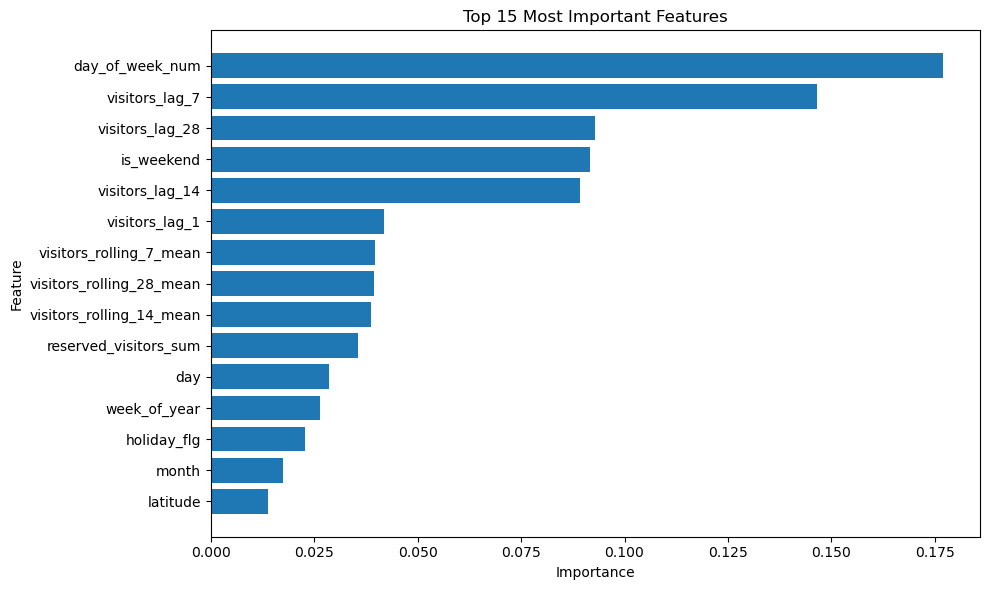

In [17]:
top_features = feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [18]:
feature_importance.to_csv(DATA_DIR / "feature_importance.csv", index=False)

print("Feature importance saved.")

Feature importance saved.


In [19]:
weekly_predictions[["air_store_id", "week_start", "week_end", "days_in_week"]]

,air_store_id,week_start,week_end,days_in_week
0,air_36bcf77d3382d36e,2017-03-13,2017-03-19,5
1,air_36bcf77d3382d36e,2017-03-20,2017-03-26,7
2,air_36bcf77d3382d36e,2017-03-27,2017-04-02,7
3,air_36bcf77d3382d36e,2017-04-03,2017-04-09,7
4,air_36bcf77d3382d36e,2017-04-10,2017-04-16,7
5,air_36bcf77d3382d36e,2017-04-17,2017-04-23,6
6,air_5c817ef28f236bdf,2017-03-13,2017-03-19,5
7,air_5c817ef28f236bdf,2017-03-20,2017-03-26,7
8,air_5c817ef28f236bdf,2017-03-27,2017-04-02,7
9,air_5c817ef28f236bdf,2017-04-03,2017-04-09,7


In [20]:
full_week_predictions = weekly_predictions[
    weekly_predictions["days_in_week"] == 7
]

full_week_predictions

,air_store_id,week_start,week_end,days_in_week,actual_weekly_visitors,predicted_weekly_visitors,predicted_weekly_visitors_rounded,average_daily_error,weekly_absolute_error,weekly_practical_accuracy_percent
1,air_36bcf77d3382d36e,2017-03-20,2017-03-26,7,229,232.442407,234,9.790082,3.442407,98.496765
2,air_36bcf77d3382d36e,2017-03-27,2017-04-02,7,192,217.716900,217,7.091003,25.716900,86.605781
3,air_36bcf77d3382d36e,2017-04-03,2017-04-09,7,230,209.081531,209,7.031488,20.918469,90.905013
4,air_36bcf77d3382d36e,2017-04-10,2017-04-16,7,231,209.493149,209,8.431653,21.506851,90.689675
7,air_5c817ef28f236bdf,2017-03-20,2017-03-26,7,299,311.894680,313,15.052331,12.894680,95.687398
8,air_5c817ef28f236bdf,2017-03-27,2017-04-02,7,345,291.093048,291,11.715380,53.906952,84.374797
9,air_5c817ef28f236bdf,2017-04-03,2017-04-09,7,299,283.908898,285,10.203872,15.091102,94.952809
10,air_5c817ef28f236bdf,2017-04-10,2017-04-16,7,296,306.217453,306,7.127939,10.217453,96.548158
13,air_a083834e7ffe187e,2017-03-20,2017-03-26,7,218,216.048341,216,2.111191,1.951659,99.104744
15,air_a083834e7ffe187e,2017-04-03,2017-04-09,7,139,171.703857,171,6.801979,32.703857,76.472045
